# Restricted Boltzmann Machines for Collaborative Filtering — Summary

# https://www.cs.toronto.edu/~rsalakhu/papers/rbmcf.pdf

## Abstract
This paper introduces a class of two-layer undirected graphical models, Restricted Boltzmann Machines (RBMs), adapted for modeling tabular data such as user movie ratings. The authors present efficient learning and inference procedures for this model class and demonstrate successful application to the Netflix dataset, containing over 100 million user/movie ratings. RBMs are shown to slightly outperform carefully-tuned Singular Value Decomposition (SVD) models, and linearly combining predictions from multiple RBM and SVD variants yields an error rate more than 6% better than Netflix's own baseline system.

## Problems
- Most existing collaborative filtering approaches cannot handle very large datasets such as Netflix's 100-million-rating corpus.
- Low-rank matrix factorization via SVD minimizes sum-squared distance, but in collaborative filtering most rating matrices are sparse (many missing entries), which makes this a difficult non-convex optimization problem — a naive SVD solution does not work well.
- Standard RBMs assume a fixed, complete set of visible units, but the Netflix data has extensive and variable missingness (different users rate different, and few, movies).
- Maximum likelihood learning in RBMs is intractable because the model's partition function and required expectations cannot be computed analytically in less than exponential time; naive MCMC approximations are slow and high-variance.
- Standard RBM parameterization over movies, ratings, and hidden features produces a very large number of free parameters (~9 million with $$F=100$$ hidden units, $$M=17{,}770$$ movies, $$K=5$$ ratings), which becomes problematic as the number of hidden features or movies grows.
- Directed graphical probabilistic models for collaborative filtering (e.g., pLSI-based approaches) suffer from intractable exact inference due to "explaining away," requiring slow or inaccurate posterior approximations.
- Maximum Margin Matrix Factorization (MMMF), an alternative to rank-constrained factorization, requires solving a sparse semi-definite program that does not scale beyond about 10,000 observations, far short of the Netflix dataset's scale.

## Proposed Solutions
- Use a per-user RBM architecture: each user has their own RBM instance containing only softmax visible units for movies that user actually rated, with weights and biases tied (shared) across all user-specific RBMs for movies in common.
- Model each column of the visible rating matrix with a conditional multinomial ("softmax") distribution over $$K$$ possible rating values, and model hidden user features with a conditional Bernoulli distribution:
$$p(v_i^k=1|\mathbf{h}) = \frac{\exp\left(b_i^k + \sum_{j=1}^F h_j W_{ij}^k\right)}{\sum_{l=1}^K \exp\left(b_i^l + \sum_{j=1}^F h_j W_{ij}^l\right)}$$
$$p(h_j=1|\mathbf{V}) = \sigma\left(b_j + \sum_{i=1}^m \sum_{k=1}^K v_i^k W_{ij}^k\right)$$
- Define the joint energy function over visible ratings and hidden features (missing ratings contribute nothing to the energy):
$$E(\mathbf{V},\mathbf{h}) = -\sum_{i=1}^m\sum_{j=1}^F\sum_{k=1}^K W_{ij}^k h_j v_i^k - \sum_{i=1}^m\sum_{k=1}^K v_i^k b_i^k - \sum_{j=1}^F h_j b_j$$
- Train using Contrastive Divergence (CD) rather than exact maximum likelihood, approximating the gradient via short Gibbs sampling chains initialized at the data:
$$\Delta W_{ij}^k = \epsilon\left(\langle v_i^k h_j\rangle_{data} - \langle v_i^k h_j\rangle_T\right)$$
- Extend the model to Gaussian hidden units (an undirected analogue of pLSI) for continuous-valued latent features.
- Introduce Conditional RBMs that incorporate a binary vector $$\mathbf{r}$$ indicating which movies a user rated (regardless of the rating value), via a learned matrix $$D$$ influencing hidden unit activation, exploiting Netflix's disclosure of which user/movie pairs appear in the test set.
- Introduce Conditional Factored RBMs that factorize the large weight tensor $$W \in \mathbb{R}^{M\times K\times F}$$ into a product of two lower-rank matrices:
$$W_{ij}^k = \sum_{c=1}^C A_{ic}^k B_{cj}$$
reducing free parameters substantially (e.g., by a factor of three with $$C=30$$).
- Compare against an SVD baseline formulated as a regularized, partially-observed low-rank factorization objective:
$$f = \sum_{i=1}^N\sum_{j=1}^M I_{ij}(\mathbf{u}_i\mathbf{v}_j' - Y_{ij})^2 + \lambda\sum_{ij} I_{ij}\left(\|\mathbf{u}_i\|^2_{Fro} + \|\mathbf{v}_j\|^2_{Fro}\right)$$
- Blend predictions from multiple RBM and SVD model variants via linear combination with coefficients tuned on validation data.

## Purpose
The goal is to demonstrate that RBMs — reformulated to efficiently handle massive, sparse, variable-length rating data — can serve as a scalable, competitive alternative (and complement) to matrix-factorization approaches for large-scale collaborative filtering, specifically targeting the Netflix Prize dataset and its evaluation protocol.

## Methodology
| Component | Description |
|---|---|
| Dataset | Netflix dataset: 100,480,507 training ratings (480,189 users × 17,770 movies), 1,408,395 validation ratings, 2,817,131 test user/movie pairs (ratings withheld, scored by Netflix) |
| Base model | Per-user RBM with $$K=5$$ softmax visible units per rated movie, symmetric weights $$W$$ shared across users for movies in common |
| Model variants | Standard RBM, RBM with Gaussian hidden units, Conditional RBM (using rated/unrated indicator $$\mathbf{r}$$), Conditional Factored RBM (low-rank factorized $$W$$) |
| Training | Contrastive Divergence with Gibbs sampling steps $$T$$ increased from 1 during training (T=3, T=5, T=9 schedules); mini-batches of 1000 users; learning rate 0.01/batch-size; momentum 0.9; weight decay 0.001; weights initialized from $$\mathcal{N}(0, 0.01^2)$$ |
| RBM hyperparameters | $$F=100$$ hidden units for standard RBM; $$F=500$$, $$C=30$$ for conditional factored RBM |
| SVD baseline | Regularized low-rank factorization via gradient descent on partially observed entries; mini-batches of 100,000 user/movie pairs; learning rate 0.005; momentum 0.9; regularization $$\lambda=0.01$$; best performance at $$C=40$$ factors (range [20,60] similar) |
| Evaluation metric | Root Mean Squared Error (RMSE) on validation set and Netflix-scored test set; Netflix's own baseline system scored 0.9514 |
| Model blending | Linear combination of predictions from multiple RBM and SVD variants, with combination weights tuned on validation data |

## Results
- The nonlinear RBM substantially outperforms its linear counterpart, the RBM with Gaussian hidden units, in RMSE over training epochs.
- Conditioning on rated/unrated information (Conditional RBM) significantly improves performance over the standard (unconditional) RBM.
- Factoring the weight matrix (Conditional Factored RBM) leads to much faster convergence than the unfactored conditional RBM, while maintaining comparable final accuracy.
- The Conditional Factored RBM slightly outperforms a well-tuned SVD model with $$C=40$$ factors, though the margin between the two is not large.
- Test-set RMSE (as scored by Netflix) is typically about 0.0014 higher than validation-set RMSE; including the validation set in training reduces test RMSE by about 0.005.
- Imputing missing ratings from the ordinary (unconditional) RBM — using either an approximate CD gradient or mean-field equations — performs comparably to using an explicit Conditional RBM, providing a viable, computationally cheaper alternative on smaller data subsets (CD-based imputation) and for the full dataset (mean-field imputation).
- Because the error patterns of RBM variants differ substantially from those of SVD variants, linearly combining predictions from multiple RBM and multiple SVD models yields an error rate more than 6% better than Netflix's own baseline system (0.9514), a materially larger improvement than any single model type achieves alone.
- Proper weight-decay regularization allows the large-parameter (~9 million parameter) standard RBM to avoid serious overfitting, though scaling further (more hidden units or movies) without factorization remains problematic.

## Conclusions
The paper demonstrates that RBMs, reformulated with per-user visible unit subsets, tied weights, softmax rating distributions, and Contrastive Divergence training, can be scaled successfully to a dataset of over 100 million ratings — a scale that defeats several competing probabilistic approaches (e.g., directed graphical models requiring intractable exact inference, or Maximum Margin Matrix Factorization requiring semi-definite programming that does not scale beyond ~10,000 observations). RBMs achieve accuracy slightly exceeding carefully-tuned SVD models, and because their error characteristics differ meaningfully from SVD's, ensembling RBM and SVD variants produces a substantially larger accuracy gain (over 6% improvement over Netflix's baseline) than either model family alone. The authors identify promising future directions, including unrolling pretrained RBMs into autoencoders fine-tuned via backpropagation, and stacking RBMs into deep belief networks, as extensions for further improving performance on the Netflix task.

# Mathematical and Statistical Content Summary

## 1. Low-Rank Matrix Model for Collaborative Filtering
$$X = UV'$$

- $$U \in \mathbb{R}^{N\times C}$$: user feature matrix (rows = user vectors).
- $$V' \in \mathbb{R}^{C\times M}$$: movie feature matrix (columns = movie vectors).
- $$C$$: number of latent features (rank).

**Role:** The baseline conceptual model for collaborative filtering — each rating is approximated as the dot product of a user vector and a movie vector. This motivates both the SVD approach and provides intuition for what the RBM's hidden features are meant to capture.

## 2. Singular Value Decomposition (SVD) Objective
$$f = \sum_{i=1}^N\sum_{j=1}^M I_{ij}(\mathbf{u}_i\mathbf{v}_j' - Y_{ij})^2 + \lambda\sum_{ij} I_{ij}\left(\|\mathbf{u}_i\|^2_{Fro} + \|\mathbf{v}_j\|^2_{Fro}\right)$$

- $$I_{ij}$$: indicator function (1 if user $$i$$ rated movie $$j$$, else 0).
- $$\|\cdot\|^2_{Fro}$$: squared Frobenius norm (regularization term).
- $$\lambda$$: regularization strength.

**Role:** Since most ratings are missing, ordinary SVD (which requires a fully observed matrix) cannot be used directly. This objective minimizes squared error only over observed entries, with L2 regularization to prevent overfitting on sparse data, and is optimized via gradient descent — this is the paper's baseline model compared against the RBM.

## 3. RBM Visible Unit Distribution (Softmax over Ratings)
$$p(v_i^k=1|\mathbf{h}) = \frac{\exp\left(b_i^k + \sum_{j=1}^F h_j W_{ij}^k\right)}{\sum_{l=1}^K \exp\left(b_i^l + \sum_{j=1}^F h_j W_{ij}^l\right)}$$

- $$v_i^k$$: indicator that movie $$i$$ was rated $$k$$.
- $$W_{ij}^k$$: interaction weight between hidden feature $$j$$ and rating value $$k$$ for movie $$i$$.
- $$b_i^k$$: bias for movie $$i$$ having rating $$k$$.

**Role:** Models each movie's rating as a categorical (multinomial/softmax) variable rather than a real number, since ratings are discrete (1 to $$K$$). This lets the RBM represent rating probabilities as a proper distribution over the $$K$$ possible values.

## 4. RBM Hidden Unit Distribution (Conditional Bernoulli)
$$p(h_j=1|\mathbf{V}) = \sigma\left(b_j + \sum_{i=1}^m\sum_{k=1}^K v_i^k W_{ij}^k\right), \quad \sigma(x) = \frac{1}{1+e^{-x}}$$

**Role:** Defines how binary latent ("hidden") features — representing abstract user taste dimensions — are activated based on the observed ratings, using the standard logistic sigmoid. This is the "inference" direction of the model (data → hidden features).

## 5. Energy Function
$$E(\mathbf{V},\mathbf{h}) = -\sum_{i=1}^m\sum_{j=1}^F\sum_{k=1}^K W_{ij}^k h_j v_i^k - \sum_{i=1}^m\sum_{k=1}^K v_i^k b_i^k - \sum_{j=1}^F h_j b_j$$

**Role:** Defines the (negative) compatibility between a configuration of visible ratings $$\mathbf{V}$$ and hidden features $$\mathbf{h}$$; lower energy means higher probability under the model. Missing ratings are simply excluded from the sums, so they contribute nothing — this is how the RBM elegantly handles sparse/missing data without needing to impute values structurally.

## 6. Marginal Distribution over Visible Ratings
$$p(\mathbf{V}) = \sum_{\mathbf{h}} \frac{\exp(-E(\mathbf{V},\mathbf{h}))}{\sum_{\mathbf{V}',\mathbf{h}'} \exp(-E(\mathbf{V}',\mathbf{h}'))}$$

**Role:** The full probabilistic model for a user's observed ratings, obtained by summing out (marginalizing) the hidden units. The denominator (partition function) requires summing over all possible configurations of both visible and hidden units — this sum is exponential in size and is the source of intractability.

## 7. Maximum Likelihood Gradient (Intractable Form)
$$\Delta W_{ij}^k = \epsilon \frac{\partial \log p(\mathbf{V})}{\partial W_{ij}^k} = \epsilon\left(\langle v_i^k h_j\rangle_{data} - \langle v_i^k h_j\rangle_{model}\right)$$

- $$\langle \cdot \rangle_{data}$$: expected co-occurrence frequency under the real training data.
- $$\langle \cdot \rangle_{model}$$: expected co-occurrence frequency under the model's own (equilibrium) distribution.
- $$\epsilon$$: learning rate.

**Role:** The theoretically correct gradient ascent rule for maximizing log-likelihood. The "model" expectation term is the crux of the intractability problem, since it requires sampling from the full model distribution (via expensive/high-variance MCMC), motivating the next concept.

## 8. Contrastive Divergence (CD) Learning Rule
$$\Delta W_{ij}^k = \epsilon\left(\langle v_i^k h_j\rangle_{data} - \langle v_i^k h_j\rangle_T\right)$$

- $$\langle \cdot \rangle_T$$: expectation from a short Gibbs sampling chain of $$T$$ steps, initialized at the training data (not run to equilibrium).

**Role:** This is the paper's core learning algorithm. Instead of the expensive/high-variance true model expectation, CD substitutes a cheap approximation obtained after only a few steps of alternating Gibbs sampling (using Eqs. for $$p(v|h)$$ and $$p(h|v)$$). This dramatically reduces computation and variance while still producing an effective (approximate) learning signal; $$T$$ is increased gradually (e.g., 1→3→5→9) as training progresses.

## 9. Prediction via Marginal Query Probability
$$p(v_q^k=1|\mathbf{V}) \propto \sum_{h_1,\ldots,h_F} \exp(-E(v_q^k,\mathbf{V},\mathbf{h})) = \Gamma_q^k \prod_{j=1}^F\left(1+\exp\left(\sum_{il} v_i^l W_{ij}^l + v_q^k W_{qj}^k + b_j\right)\right)$$

where $$\Gamma_q^k = \exp(v_q^k b_q^k)$$.

**Role:** Gives an exact, closed-form way (linear in the number of hidden units) to compute an unnormalized score for a candidate rating $$k$$ on a new "query" movie $$q$$, without needing sampling — because the hidden units can be summed out analytically for a single query movie. Normalizing across $$K$$ values and taking the expectation gives the predicted rating.

## 10. Joint Query Probability for Multiple Movies
$$p(v_{q_1}^{k_1}=1, v_{q_2}^{k_2}=1, \ldots, v_{q_n}^{k_n}=1 \mid \mathbf{V})$$

**Role:** Generalizes the single-movie prediction to simultaneous predictions for $$n$$ movies, but requires $$K^n$$ evaluations per user, making it computationally impractical for large $$n$$ — motivating the mean-field approximation below.

## 11. Mean-Field Approximation for Prediction
$$\hat{p}_j = p(h_j=1|\mathbf{V}) = \sigma\left(b_j + \sum_{i=1}^m\sum_{k=1}^K v_i^k W_{ij}^k\right)$$
$$p(v_q^k=1|\hat{\mathbf{p}}) = \frac{\exp\left(b_q^k + \sum_{j=1}^F \hat{p}_j W_{qj}^k\right)}{\sum_{l=1}^K \exp\left(b_q^l + \sum_{j=1}^F \hat{p}_j W_{qj}^l\right)}$$

**Role:** A faster, approximate alternative to Eq. 7 that replaces stochastic hidden unit sampling with their expected (mean-field) activation probabilities, used in practice in the paper's experiments because it is considerably faster despite being slightly less accurate.

## 12. Gaussian Hidden Unit Extension
$$p(h_j=h|\mathbf{V}) = \frac{1}{\sqrt{2\pi\sigma_j}}\exp\left(-\frac{\left(h - b_j - \sigma_j\sum_{ik} v_i^k W_{ij}^k\right)^2}{2\sigma_j^2}\right)$$

with energy:
$$E(\mathbf{V},\mathbf{h}) = -\sum_{ijk} W_{ij}^k \frac{h_j}{\sigma_j} v_i^k - \sum_{ik} v_i^k b_i^k + \sum_j \frac{(h_j-b_j)^2}{2\sigma_j^2}$$

**Role:** Replaces binary hidden units with continuous, Gaussian-distributed hidden units (variance $$\sigma_j^2$$, fixed to 1 in experiments), forming an undirected analogue of probabilistic latent semantic indexing (pLSI). This lets hidden "taste" features take graded, real values rather than being purely on/off.

## 13. Conditional RBM (Rated/Unrated Indicator)
$$p(h_j=1|\mathbf{V},\mathbf{r}) = \sigma\left(b_j + \sum_{i=1}^m\sum_{k=1}^K v_i^k W_{ij}^k + \sum_{i=1}^M r_i D_{ij}\right)$$
$$\Delta D_{ij} = \epsilon\left(\langle h_j\rangle_{data} - \langle h_j\rangle_T\right) r_i$$

- $$\mathbf{r} \in \{0,1\}^M$$: indicator of which movies a user rated (regardless of rating value).
- $$D$$: learned matrix capturing the effect of the rated/unrated pattern on hidden features.

**Role:** Exploits an extra source of information — Netflix reveals in advance which user/movie pairs appear in the test set, so simply knowing a user rated a certain movie (even without knowing the rating) is informative. This equation lets that binary "rated vs. not rated" pattern directly influence the hidden representation, and is learned with the same contrastive divergence principle as the weights.

## 14. Generalization to an Arbitrary Nonlinear Function via Backpropagation
$$\Delta \theta = \epsilon\left(\langle h_j\rangle_{data} - \langle h_j\rangle_T\right)\frac{\partial f(\mathbf{r}|\theta)}{\partial \theta}$$

**Role:** Shows that the linear $$D$$ matrix used above can be replaced by any differentiable function $$f(\mathbf{r}|\theta)$$ (e.g., a multi-layer neural network) whose parameters $$\theta$$ are updated via the same contrastive-divergence-derived error signal combined with standard backpropagation — a generalization enabling more flexible conditioning mechanisms.

## 15. Imputation of Missing Ratings via CD Gradient
$$\Delta v_t^k = \epsilon\left(\left\langle \sum_j W_t^k h_j\right\rangle_{data} - \left\langle \sum_j W_t^k h_j\right\rangle_T\right)$$

**Role:** An alternative to the Conditional RBM: instead of explicitly conditioning on which movies were rated, missing rating values are treated as free variables initialized at the movie's base rate and updated via an approximate CD gradient, then renormalized into a valid probability distribution over $$K$$ values. This lets missing values indirectly inform the hidden units without a separate conditioning mechanism.

## 16. Factored RBM (Low-Rank Weight Tensor Decomposition)
$$W_{ij}^k = \sum_{c=1}^C A_{ic}^k B_{cj}, \qquad C \ll M, \ C \ll F$$

with learning updates:
$$\Delta A_{ic}^k = \epsilon\left(\left\langle \Big[\sum_j B_{cj}h_j\Big]v_i^k\right\rangle_{data} - \left\langle \Big[\sum_j B_{cj}h_j\Big]v_i^k\right\rangle_T\right)$$
$$\Delta B_{cj} = \epsilon\left(\left\langle \Big[\sum_{ik} A_{ic}^k v_i^k\Big]h_j\right\rangle_{data} - \left\langle \Big[\sum_{ik} A_{ic}^k v_i^k\Big]h_j\right\rangle_T\right)$$

**Role:** Addresses the very large parameter count of the full weight tensor $$W \in \mathbb{R}^{M\times K\times F}$$ (~9 million parameters in the paper's setup) by factorizing it into two much smaller matrices $$A$$ and $$B$$ via a shared low-rank dimension $$C$$ (e.g., $$C=30$$), reducing free parameters (here, by roughly a factor of three) while preserving most of the model's expressive capacity — directly analogous to low-rank matrix factorization but applied within the RBM's weight tensor.

## 17. Evaluation Metric: Root Mean Squared Error (RMSE)
Used throughout (not explicitly written as an equation in the excerpt, but standard):
$$\text{RMSE} = \sqrt{\frac{1}{|\mathcal{T}|}\sum_{(i,j)\in\mathcal{T}} (\hat{Y}_{ij} - Y_{ij})^2}$$

**Role:** The paper's sole quantitative evaluation metric, used to compare all models (RBM variants, SVD, Netflix's baseline) on validation and Netflix-scored test data. Netflix's own baseline achieves RMSE 0.9514; validation-set RMSE is reported to run about 0.0014 lower than the corresponding Netflix test-set RMSE.

## 18. Statistical/Experimental Methodology
- **Mini-batch stochastic optimization**: RBMs trained with mini-batches of 1,000 users; SVD trained with mini-batches of 100,000 user/movie pairs — a standard variance-reduction and computational-efficiency technique for large-scale gradient-based learning.
- **Momentum-based gradient updates** (momentum = 0.9) and **weight decay** (0.001 for RBM, via $$\lambda=0.01$$ regularization for SVD) — standard optimization/regularization techniques to accelerate convergence and control overfitting.
- **Model selection via validation set**: choice of $$C$$ (number of SVD factors, tested in range [20,60], best at $$C=40$$) and combination weights for model blending are tuned using held-out validation data rather than the test set, to avoid overfitting to the evaluation criterion.
- **Linear ensembling**: final predictions combine multiple RBM and SVD variants via a linear combination whose coefficients are fit on validation data — a simple form of stacked/ensemble regression exploiting the fact that RBM and SVD models make substantially different errors, yielding an improvement (>6% over baseline) larger than any individual model.

## Summary of Mathematical Contribution
The paper's mathematical core is an adaptation of the standard RBM energy-based framework (softmax visible units, Bernoulli or Gaussian hidden units, energy function, and Contrastive Divergence training) to handle massive-scale, highly sparse rating data, where missing entries are simply excluded from all sums rather than requiring imputation. Key extensions — conditioning on a rated/unrated indicator vector, backpropagation-based conditioning functions, and low-rank factorization of the weight tensor — address information usage and parameter-efficiency challenges specific to the Netflix setting. The evaluation methodology (RMSE, validation-tuned hyperparameters, and linear ensembling of statistically distinct model families) reflects standard, sound empirical machine learning practice rather than novel statistical theory.

# Research Gaps and Proposed Solutions

| # | Key Problem / Research Gap | Limitation of Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | Most existing collaborative filtering approaches cannot handle very large datasets. | Methods that work well on small or moderate-sized datasets fail to scale to real-world databases like Netflix's, which contains over 100 million ratings. | Reformulate RBMs with per-user model instances and tied weights, combined with efficient Contrastive Divergence training, to make learning tractable at this scale. |
| 2 | Low-rank matrix factorization via SVD requires a fully observed target matrix, but collaborative filtering matrices are highly sparse. | As shown by Srebro and Jaakkola (2003), minimizing sum-squared distance on sparse data creates a difficult non-convex optimization problem, so naive SVD solutions do not work. | Formulate a regularized SVD objective that minimizes squared error only over the observed (non-missing) entries, using an indicator function $$I_{ij}$$, optimized via gradient descent as a practical baseline. |
| 3 | Standard RBMs assume a fixed, complete set of visible units, but Netflix users rate widely varying and typically small subsets of movies. | A single shared RBM structure cannot efficiently represent per-user data where the set of "active" visible units differs drastically from user to user. | Use a separate RBM per user containing only the softmax visible units for movies that user actually rated, with weights and biases tied across users for movies rated in common. |
| 4 | Maximum likelihood learning in RBMs is intractable, since exact gradients require computing an expectation under the model's equilibrium distribution. | Naive approaches use MCMC methods (e.g., Neal, 1993) to approximate this expectation, but these are slow and produce high-variance gradient estimates, hampering efficient learning at scale. | Apply Contrastive Divergence (Hinton, 2002), approximating the intractable model expectation with samples from a short, data-initialized Gibbs sampling chain of $$T$$ steps, increasing $$T$$ as training progresses. |
| 5 | The standard RBM parameterization over movies, ratings, and hidden features produces an extremely large number of free parameters. | With $$F=100$$ hidden units, $$M=17{,}770$$ movies, and $$K=5$$ ratings, the model has about 9 million parameters; increasing hidden units or movie count further makes learning the full weight tensor problematic, while simply reducing hidden units limits model expressiveness. | Introduce a Conditional Factored RBM that factorizes the weight tensor $$W_{ij}^k$$ into a product of two lower-rank matrices $$A$$ and $$B$$ via a shared dimension $$C \ll M, F$$, substantially reducing free parameters while preserving expressiveness. |
| 6 | A valuable source of information in the Netflix data — which user/movie pairs appear in the test set (rated vs. unrated, independent of rating value) — is not captured by the standard multinomial RBM. | Users who rated few movies in training but are known to have rated specific movies (even with unknown rating) provide informative signal that a standard RBM ignores, since it only reconstructs non-missing ratings. | Introduce a Conditional RBM that incorporates a binary rated/unrated indicator vector $$\mathbf{r}$$ via a learned matrix $$D$$ (or an arbitrary differentiable function trained via backpropagation) that influences hidden unit activations. |
| 7 | Directed graphical probabilistic models proposed for collaborative filtering (e.g., pLSI-based approaches) suffer from intractable exact inference. | Due to "explaining away" in directed models, computing the posterior distribution over hidden factors requires slow or inaccurate approximations (Welling et al., 2005). | Use RBMs, which as undirected graphical models avoid the explaining-away problem, allowing more tractable (though still approximate, via CD) inference and learning. |
| 8 | Maximum Margin Matrix Factorization (MMMF) offers an alternative to rank-constrained factorization by constraining factor norms instead of the number of factors. | Learning MMMF requires solving a sparse semi-definite program, and generic SDP solvers struggle beyond about 10,000 observations, far short of the Netflix dataset's scale (100+ million ratings). | Rather than pursuing SDP-based optimization, use RBMs trained via mini-batch Contrastive Divergence, which scales efficiently to datasets of this size. |
| 9 | It was unclear whether a single model family (RBM or SVD alone) could substantially outperform Netflix's own baseline system. | Individual well-tuned models (RBM or SVD) each only modestly outperform the Netflix baseline, and their errors, if considered separately, do not maximize potential accuracy gains. | Demonstrate that RBM and SVD variants make substantially different errors, and use linear combination of predictions from multiple RBM and SVD models (with coefficients tuned on validation data) to achieve over 6% improvement over Netflix's baseline. |
| 10 | Existing RBM-based collaborative filtering had not been explored as a foundation for deeper or autoencoder-style architectures on rating data. | Without further extension, the shallow two-layer RBM's representational capacity for capturing complex user-preference structure remains limited. | Propose future extensions: unrolling a pretrained RBM into a backpropagation-finetuned autoencoder, and stacking RBMs into deep belief networks, drawing on prior success of such deep architectures in other domains (e.g., dimensionality reduction, MNIST classification). |

In [1]:
# ============================================================
# EDUCATIONAL REPLICATION: "Restricted Boltzmann Machines for
# Collaborative Filtering" (Salakhutdinov, Mnih & Hinton, ICML 2007)
#
# The original paper trains RBMs (with softmax/Gaussian visible units)
# via CONTRASTIVE DIVERGENCE (CD) to model sparse rating data, then
# reads out predictions from the learned hidden features. Section 8.1
# ("Learning Autoencoders") also describes using the pretrained RBM as
# an initialization for a backprop-finetuned reconstruction network.
#
# This replication adapts those exact core ideas to CIFAR-10 image
# classification:
#   - A Gaussian-Bernoulli RBM (continuous visible units for pixel
#     intensities, binary hidden "feature" units) trained via
#     CONTRASTIVE DIVERGENCE (CD-k), exactly as in the paper's core
#     learning rule (Eq. 6): dW = eps * (<v h>_data - <v h>_T).
#   - A linear CLASSIFIER trained on top of the RBM's hidden feature
#     probabilities, jointly with the RBM's own CD-based updates,
#     mirroring the paper's Section 8.1 "unrolled RBM as pretraining +
#     supervised fine-tuning" idea.
#   - Two distinct loss/objective components tracked separately, as in
#     the paper: (1) CD reconstruction error (RBM's own training signal)
#     and (2) supervised classification cross-entropy loss.
#
# NOTE: This code is NOT executed here. Copy into Google Colab / Jupyter.
# ============================================================

# ---------------------------------------------------------------
# 0. IMPORTS
# ---------------------------------------------------------------
import io
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision.transforms as T

from datasets import load_dataset  # HuggingFace datasets (mandatory source)

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sklearn.metrics import confusion_matrix

from IPython.display import display, Image as IPImage

In [2]:
# ---------------------------------------------------------------
# GLOBAL WHITE-THEME SETTINGS (applied globally + reinforced per-axis later)
# ---------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "grid.color": "#d9d9d9",
    "legend.labelcolor": "black",
    "font.size": 10,
})

In [3]:
# ---------------------------------------------------------------
# REPRODUCIBILITY
# ---------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# ---------------------------------------------------------------
# 1. CLASS NAMES (CIFAR-10, exact order, labels 0-9)
# ---------------------------------------------------------------
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]
NUM_CLASSES = len(CLASS_NAMES)

In [ ]:
# ---------------------------------------------------------------
# 2. DATASET PREPARATION (HuggingFace CIFAR-10 — mandatory source)
# ---------------------------------------------------------------
ds = load_dataset("uoft-cs/cifar10")

train_transform = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class HFCifar10Dataset(Dataset):
    """
    Wraps a HuggingFace CIFAR-10 split into a standard PyTorch Dataset.
    Reads the 'img' field as a PIL image, converts to RGB, applies the
    given torchvision transform, and returns (image_tensor, label).
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        sample = self.hf_split[idx]
        img = sample["img"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img_tensor = self.transform(img)
        label = int(sample["label"])
        return img_tensor, label


train_full = HFCifar10Dataset(ds["train"], train_transform)
test_full = HFCifar10Dataset(ds["test"], test_transform)

# Small subsets for a fast, educational 5-epoch run
train_subset = Subset(train_full, list(range(2000)))
test_subset = Subset(test_full, list(range(400)))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False, num_workers=2)

In [6]:
# ---------------------------------------------------------------
# SANITY CHECK
# ---------------------------------------------------------------
sanity_images, sanity_labels = next(iter(train_loader))
print("Number of training samples:", len(train_subset))
print("Number of test samples:", len(test_subset))
print("Shape of one batch of images:", sanity_images.shape)
print("Label range: [{}, {}]".format(sanity_labels.min().item(), sanity_labels.max().item()))
print("First 8 class names in batch:", [CLASS_NAMES[l] for l in sanity_labels[:8].tolist()])

Number of training samples: 2000
Number of test samples: 400
Shape of one batch of images: torch.Size([64, 3, 64, 64])
Label range: [0, 9]
First 8 class names in batch: ['deer', 'automobile', 'frog', 'deer', 'horse', 'cat', 'deer', 'ship']


In [7]:
# ---------------------------------------------------------------
# 3. MODEL DEFINITION — Gaussian-Bernoulli RBM + Linear Classifier
# ---------------------------------------------------------------
#
# Core RBM equations from the paper, adapted here:
#   p(h_j=1|v) = sigmoid(b_j + sum_i v_i * W_ij)          (Eq. 2 analogue)
#   p(v_i | h) = Gaussian(mean = b_i + sum_j h_j * W_ij, var=1)  (Sec. 3)
#   Energy:    E(v,h) = -sum_ij W_ij h_j v_i - sum_i (v_i-b_i)^2/2
#                       - sum_j h_j b_j                    (Eq. 11 analogue)
#   CD update: dW = eps * (<v h>_data - <v h>_T)           (Eq. 6)
#
# Images are flattened into a single "visible" vector per RBM (treating
# pixel intensities as the continuous Gaussian visible units described
# in Section 3, "RBM's with Gaussian Hidden Units" is inverted here:
# we use Gaussian VISIBLE units and Bernoulli HIDDEN units, the more
# standard Gaussian-Bernoulli RBM, which is the natural counterpart
# for continuous pixel data while keeping hidden features binary as
# in the paper's main model).

IMG_SIZE = 64
IMG_CHANNELS = 3
VISIBLE_DIM = IMG_CHANNELS * IMG_SIZE * IMG_SIZE
NUM_HIDDEN = 256          # F in the paper's notation
CD_K = 1                  # number of Gibbs steps for Contrastive Divergence (T in Eq. 6)
RBM_LR = 0.01              # RBM's own Contrastive Divergence learning rate (paper Sec 6.2)


class GaussianBernoulliRBM(nn.Module):
    """
    A Gaussian-Bernoulli RBM: continuous visible units (pixel intensities),
    binary hidden units (learned "taste"/feature detectors, analogous to
    the paper's hidden user-feature units). Trained via Contrastive
    Divergence (CD-k), following the paper's Eq. 6 update rule.
    """
    def __init__(self, visible_dim, hidden_dim):
        super().__init__()
        self.visible_dim = visible_dim
        self.hidden_dim = hidden_dim

        # W: symmetric interaction weights between visible and hidden units
        self.W = nn.Parameter(0.01 * torch.randn(visible_dim, hidden_dim))
        self.v_bias = nn.Parameter(torch.zeros(visible_dim))  # b_i in the paper
        self.h_bias = nn.Parameter(torch.zeros(hidden_dim))   # b_j in the paper

    def hidden_probs(self, v):
        """p(h_j=1|v) = sigmoid(b_j + v @ W)  -- Eq. 2 analogue."""
        return torch.sigmoid(v @ self.W + self.h_bias)

    def sample_hidden(self, v):
        probs = self.hidden_probs(v)
        return probs, torch.bernoulli(probs)

    def visible_mean(self, h):
        """Mean of Gaussian visible units given hidden states (Sec. 3)."""
        return h @ self.W.t() + self.v_bias

    def sample_visible(self, h):
        mean = self.visible_mean(h)
        # Gaussian visible units with fixed unit variance, as in the paper
        return mean, mean + torch.randn_like(mean)

    def contrastive_divergence_step(self, v_data, k=CD_K):
        """
        Runs k steps of Gibbs sampling (Eqs. 1/2 analogues), starting
        from the data, exactly as required by CD-k (Eq. 6). Returns the
        positive-phase hidden probs (data-driven) and the negative-phase
        (reconstructed) visible/hidden samples needed for the CD update.
        """
        h_probs_data, h_sample = self.sample_hidden(v_data)
        v_sample = v_data
        h_sample_current = h_sample
        for _ in range(k):
            v_mean, v_sample = self.sample_visible(h_sample_current)
            h_probs_model, h_sample_current = self.sample_hidden(v_sample)
        return h_probs_data, v_data, h_probs_model, v_sample

    def cd_update(self, v_data, k=CD_K, lr=RBM_LR):
        """
        Implements the paper's Contrastive Divergence weight update
        (Eq. 6): dW = eps * (<v h>_data - <v h>_T), applied manually
        (outside the autograd graph) since CD is not a standard
        backprop gradient but an approximation to it.
        """
        with torch.no_grad():
            h_probs_data, v_pos, h_probs_model, v_neg = self.contrastive_divergence_step(v_data, k)

            batch_size = v_data.size(0)
            # Positive phase statistics: <v h>_data
            pos_assoc = v_pos.t() @ h_probs_data / batch_size
            # Negative phase statistics: <v h>_T (after k Gibbs steps)
            neg_assoc = v_neg.t() @ h_probs_model / batch_size

            self.W += lr * (pos_assoc - neg_assoc)
            self.v_bias += lr * (v_pos - v_neg).mean(dim=0)
            self.h_bias += lr * (h_probs_data - h_probs_model).mean(dim=0)

            # Reconstruction error as a monitoring proxy for CD training
            # progress (the paper itself uses RMSE as its evaluation metric)
            recon_error = F.mse_loss(v_neg, v_pos).item()
        return recon_error


class RBMClassifier(nn.Module):
    """
    Combines the Gaussian-Bernoulli RBM's hidden feature probabilities
    with a linear classifier trained via standard backpropagation, as
    in the paper's Section 8.1 "unrolled RBM as pretraining + supervised
    fine-tuning" idea (Fig. 5).
    """
    def __init__(self, visible_dim=VISIBLE_DIM, hidden_dim=NUM_HIDDEN, num_classes=NUM_CLASSES):
        super().__init__()
        self.rbm = GaussianBernoulliRBM(visible_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        v = x.view(x.size(0), -1)  # flatten image to visible vector
        h_probs = self.rbm.hidden_probs(v)  # use hidden probs as features (mean-field, Eq. 9 analogue)
        logits = self.classifier(h_probs)
        return logits, h_probs, v


model = RBMClassifier().to(DEVICE)

In [8]:
# ---------------------------------------------------------------
# 4. LOSSES / OBJECTIVES
# ---------------------------------------------------------------
# TWO distinct training objectives, exactly mirroring the paper's two
# core learning signals:
#   (a) RBM Contrastive Divergence reconstruction error (Eq. 6) — this
#       updates the RBM's W, v_bias, h_bias via the manual CD rule.
#   (b) Supervised classification cross-entropy loss — this updates the
#       classifier (and, via backprop, also nudges the RBM's hidden
#       feature usage), mirroring the paper's autoencoder fine-tuning
#       extension (Sec. 8.1).

NUM_EPOCHS = 5
classification_criterion = nn.CrossEntropyLoss()
classifier_optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)

In [9]:
# ---------------------------------------------------------------
# 5. TRAINING LOOP + VALIDATION/EVALUATION
# ---------------------------------------------------------------
history = {
    "train_loss_total": [],
    "val_loss_total": [],
    "train_loss_class": [],
    "val_loss_class": [],
    "train_loss_cd_recon": [],   # RBM's own CD reconstruction error
    "val_loss_cd_recon": [],
    "train_acc": [],
    "val_acc": [],
    "epoch_per_class_acc": [],
}


def run_epoch(loader, train_mode):
    if train_mode:
        model.classifier.train()
    else:
        model.classifier.eval()

    total_class_loss, total_cd_recon, total_correct, total_count = 0.0, 0.0, 0, 0
    all_preds, all_labels, all_confidences = [], [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        v = imgs.view(imgs.size(0), -1)

        if train_mode:
            # --- (a) RBM Contrastive Divergence update (manual, Eq. 6) ---
            cd_recon_error = model.rbm.cd_update(v, k=CD_K, lr=RBM_LR)

            # --- (b) Classifier supervised update (standard backprop) ---
            classifier_optimizer.zero_grad()
            logits, h_probs, _ = model(imgs)
            class_loss = classification_criterion(logits, labels)
            class_loss.backward()
            classifier_optimizer.step()
        else:
            with torch.no_grad():
                logits, h_probs, _ = model(imgs)
                class_loss = classification_criterion(logits, labels)
                # Monitor CD reconstruction error (no update) for validation
                h_probs_data, v_sample = model.rbm.sample_hidden(v)[0], v
                v_mean_recon = model.rbm.visible_mean(torch.bernoulli(h_probs_data))
                cd_recon_error = F.mse_loss(v_mean_recon, v).item()

        probs = F.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)
        confs = probs.max(dim=1).values

        batch_size = imgs.size(0)
        total_class_loss += class_loss.item() * batch_size
        total_cd_recon += cd_recon_error * batch_size
        total_correct += (preds == labels).sum().item()
        total_count += batch_size

        all_preds.append(preds.detach().cpu())
        all_labels.append(labels.detach().cpu())
        all_confidences.append(confs.detach().cpu())

    avg_class = total_class_loss / total_count
    avg_cd_recon = total_cd_recon / total_count
    avg_total = avg_class + avg_cd_recon  # combined monitoring total
    avg_acc = total_correct / total_count

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_confidences = torch.cat(all_confidences).numpy()

    return avg_total, avg_class, avg_cd_recon, avg_acc, all_preds, all_labels, all_confidences


print("\nStarting training...\n")
for epoch in range(1, NUM_EPOCHS + 1):
    train_total, train_class, train_cd, train_acc, _, _, _ = run_epoch(train_loader, train_mode=True)
    val_total, val_class, val_cd, val_acc, val_preds, val_labels, val_conf = run_epoch(test_loader, train_mode=False)

    per_class_acc = np.zeros(NUM_CLASSES)
    for c in range(NUM_CLASSES):
        mask = (val_labels == c)
        per_class_acc[c] = (val_preds[mask] == c).mean() if mask.sum() > 0 else 0.0

    history["train_loss_total"].append(train_total)
    history["val_loss_total"].append(val_total)
    history["train_loss_class"].append(train_class)
    history["val_loss_class"].append(val_class)
    history["train_loss_cd_recon"].append(train_cd)
    history["val_loss_cd_recon"].append(val_cd)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["epoch_per_class_acc"].append(per_class_acc)

    print(f"Epoch {epoch}/{NUM_EPOCHS} | "
          f"Train Loss: {train_total:.4f} (Class {train_class:.4f}, CD-Recon {train_cd:.4f}) "
          f"Acc: {train_acc:.4f} | "
          f"Val Loss: {val_total:.4f} (Class {val_class:.4f}, CD-Recon {val_cd:.4f}) "
          f"Acc: {val_acc:.4f}")


Starting training...

Epoch 1/5 | Train Loss: 4.1134 (Class 2.2824, CD-Recon 1.8310) Acc: 0.1405 | Val Loss: 2.9922 (Class 2.1939, CD-Recon 0.7982) Acc: 0.2225
Epoch 2/5 | Train Loss: 3.8293 (Class 2.1705, CD-Recon 1.6587) Acc: 0.2185 | Val Loss: 2.7815 (Class 2.1078, CD-Recon 0.6737) Acc: 0.2500
Epoch 3/5 | Train Loss: 3.6884 (Class 2.1045, CD-Recon 1.5840) Acc: 0.2470 | Val Loss: 2.7021 (Class 2.0779, CD-Recon 0.6243) Acc: 0.2475
Epoch 4/5 | Train Loss: 3.6078 (Class 2.0607, CD-Recon 1.5471) Acc: 0.2620 | Val Loss: 2.6543 (Class 2.0571, CD-Recon 0.5972) Acc: 0.2875
Epoch 5/5 | Train Loss: 3.5563 (Class 2.0350, CD-Recon 1.5213) Acc: 0.2680 | Val Loss: 2.6238 (Class 2.0555, CD-Recon 0.5683) Acc: 0.2775


In [10]:
# ---------------------------------------------------------------
# 6. PREDICTION PIPELINE (final evaluation pass for visualizations)
# ---------------------------------------------------------------
(final_val_total, final_val_class, final_val_cd, final_val_acc,
 final_preds, final_labels, final_conf) = run_epoch(test_loader, train_mode=False)

# Grab one batch of images for sample-prediction visualization
sample_imgs, sample_labels = next(iter(test_loader))
with torch.no_grad():
    sample_logits, sample_h_probs, sample_v = model(sample_imgs.to(DEVICE))
    sample_probs = F.softmax(sample_logits, dim=1)
    sample_preds = sample_probs.argmax(dim=1).cpu().numpy()
    sample_conf = sample_probs.max(dim=1).values.cpu().numpy()
sample_labels_np = sample_labels.numpy()


def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

In [11]:
# ---------------------------------------------------------------
# 7. STANDALONE EDUCATIONAL VISUALIZATIONS
# ---------------------------------------------------------------

# --- Sample predictions (true vs predicted, with confidence) ---
fig_samples, axes_samples = plt.subplots(2, 4, figsize=(12, 6), facecolor="white")
for idx, ax in enumerate(axes_samples.flat):
    ax.set_facecolor("white")
    img_np = denormalize(sample_imgs[idx])
    ax.imshow(img_np)
    true_name = CLASS_NAMES[sample_labels_np[idx]]
    pred_name = CLASS_NAMES[sample_preds[idx]]
    color = "green" if true_name == pred_name else "red"
    ax.set_title(f"T: {true_name}\nP: {pred_name} ({sample_conf[idx]:.2f})",
                 color=color, fontsize=9)
    ax.axis("off")
fig_samples.suptitle("Sample Predictions (True vs Predicted)", color="black", fontsize=13)
plt.close(fig_samples)  # consolidated view is the dashboard below

/tmp/ipykernel_6911/2327787461.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axE.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)


Text(0.5, 0.995, 'RBM (Gaussian-Bernoulli) + Classifier — CIFAR-10 Educational Dashboard\n(Replication of Salakhutdinov, Mnih & Hinton, 2007 — CD training + supervised readout)')

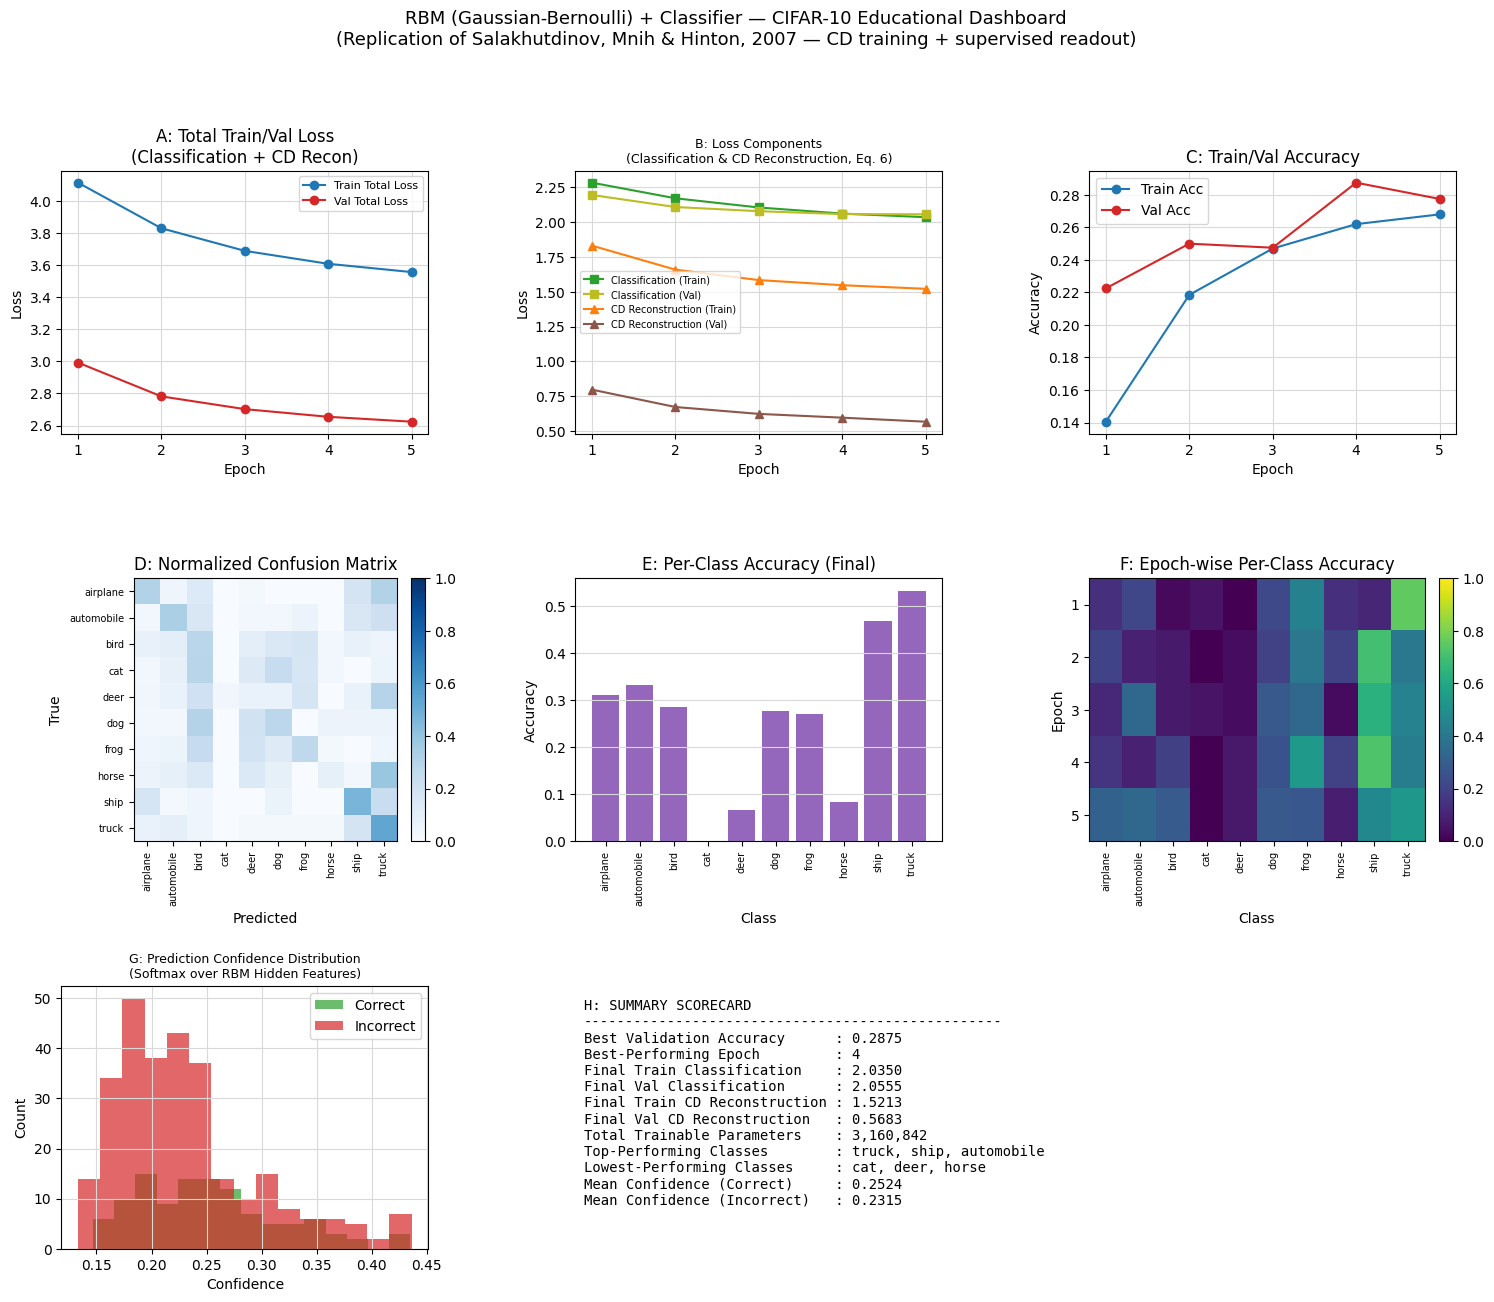

In [12]:
# ---------------------------------------------------------------
# 8. FINAL SUMMARY DASHBOARD (Panels A-H, 3-row GridSpec)
# ---------------------------------------------------------------

epochs_range = range(1, NUM_EPOCHS + 1)

cm_raw = confusion_matrix(final_labels, final_preds, labels=list(range(NUM_CLASSES)))
cm_norm = cm_raw.astype(float) / (cm_raw.sum(axis=1, keepdims=True) + 1e-9)

best_val_epoch = int(np.argmax(history["val_acc"])) + 1
best_val_acc = float(np.max(history["val_acc"]))
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

per_class_acc_final = np.zeros(NUM_CLASSES)
for c in range(NUM_CLASSES):
    mask = (final_labels == c)
    per_class_acc_final[c] = (final_preds[mask] == c).mean() if mask.sum() > 0 else 0.0

top_classes_idx = np.argsort(per_class_acc_final)[::-1][:3]
low_classes_idx = np.argsort(per_class_acc_final)[:3]

correct_mask = (final_preds == final_labels)
mean_conf_correct = final_conf[correct_mask].mean() if correct_mask.sum() > 0 else 0.0
mean_conf_incorrect = final_conf[~correct_mask].mean() if (~correct_mask).sum() > 0 else 0.0

fig = plt.figure(figsize=(18, 14), facecolor="white")
gs = GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

# ---- Panel A: Total training & validation loss ----
axA = fig.add_subplot(gs[0, 0])
axA.set_facecolor("white")
axA.plot(epochs_range, history["train_loss_total"], marker="o", color="tab:blue", label="Train Total Loss")
axA.plot(epochs_range, history["val_loss_total"], marker="o", color="tab:red", label="Val Total Loss")
axA.set_title("A: Total Train/Val Loss\n(Classification + CD Recon)", color="black")
axA.set_xlabel("Epoch", color="black")
axA.set_ylabel("Loss", color="black")
axA.legend(labelcolor="black", fontsize=8)
axA.grid(True, color="#d9d9d9")
for spine in axA.spines.values():
    spine.set_color("black")

# ---- Panel B: Task-specific loss components ----
# The paper's RBM training has TWO distinct objectives: (1) the RBM's
# own Contrastive Divergence reconstruction signal (Eq. 6), and (2) the
# supervised classification objective added for this readout task
# (mirroring Section 8.1's autoencoder fine-tuning idea). Each gets its
# own dedicated sub-curve here.
axB = fig.add_subplot(gs[0, 1])
axB.set_facecolor("white")
axB.plot(epochs_range, history["train_loss_class"], marker="s", color="tab:green",
         label="Classification (Train)")
axB.plot(epochs_range, history["val_loss_class"], marker="s", color="tab:olive",
         label="Classification (Val)")
axB.plot(epochs_range, history["train_loss_cd_recon"], marker="^", color="tab:orange",
         label="CD Reconstruction (Train)")
axB.plot(epochs_range, history["val_loss_cd_recon"], marker="^", color="tab:brown",
         label="CD Reconstruction (Val)")
axB.set_title("B: Loss Components\n(Classification & CD Reconstruction, Eq. 6)", color="black", fontsize=9)
axB.set_xlabel("Epoch", color="black")
axB.set_ylabel("Loss", color="black")
axB.legend(labelcolor="black", fontsize=7)
axB.grid(True, color="#d9d9d9")
for spine in axB.spines.values():
    spine.set_color("black")

# ---- Panel C: Training & validation accuracy ----
axC = fig.add_subplot(gs[0, 2])
axC.set_facecolor("white")
axC.plot(epochs_range, history["train_acc"], marker="o", color="tab:blue", label="Train Acc")
axC.plot(epochs_range, history["val_acc"], marker="o", color="tab:red", label="Val Acc")
axC.set_title("C: Train/Val Accuracy", color="black")
axC.set_xlabel("Epoch", color="black")
axC.set_ylabel("Accuracy", color="black")
axC.legend(labelcolor="black")
axC.grid(True, color="#d9d9d9")
for spine in axC.spines.values():
    spine.set_color("black")

# ---- Panel D: Normalized confusion matrix ----
axD = fig.add_subplot(gs[1, 0])
im = axD.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
axD.set_title("D: Normalized Confusion Matrix", color="black")
axD.set_xlabel("Predicted", color="black")
axD.set_ylabel("True", color="black")
axD.set_xticks(range(NUM_CLASSES))
axD.set_yticks(range(NUM_CLASSES))
axD.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axD.set_yticklabels(CLASS_NAMES, color="black", fontsize=7)
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar.ax.get_yticklabels(), color="black")
for spine in axD.spines.values():
    spine.set_color("black")

# ---- Panel E: Per-class accuracy bar chart ----
axE = fig.add_subplot(gs[1, 1])
axE.set_facecolor("white")
axE.bar(CLASS_NAMES, per_class_acc_final, color="tab:purple")
axE.set_title("E: Per-Class Accuracy (Final)", color="black")
axE.set_xlabel("Class", color="black")
axE.set_ylabel("Accuracy", color="black")
axE.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axE.tick_params(axis="y", colors="black")
axE.grid(True, axis="y", color="#d9d9d9")
for spine in axE.spines.values():
    spine.set_color("black")

# ---- Panel F: Epoch-wise per-class accuracy heatmap ----
axF = fig.add_subplot(gs[1, 2])
heatmap_data = np.stack(history["epoch_per_class_acc"], axis=0)  # (epochs, classes)
imF = axF.imshow(heatmap_data, cmap="viridis", aspect="auto", vmin=0, vmax=1)
axF.set_title("F: Epoch-wise Per-Class Accuracy", color="black")
axF.set_xlabel("Class", color="black")
axF.set_ylabel("Epoch", color="black")
axF.set_xticks(range(NUM_CLASSES))
axF.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axF.set_yticks(range(NUM_EPOCHS))
axF.set_yticklabels([str(e + 1) for e in range(NUM_EPOCHS)], color="black")
cbarF = fig.colorbar(imF, ax=axF, fraction=0.046, pad=0.04)
cbarF.ax.yaxis.set_tick_params(color="black")
plt.setp(cbarF.ax.get_yticklabels(), color="black")
for spine in axF.spines.values():
    spine.set_color("black")

# ---- Panel G: Confidence distribution histogram ----
axG = fig.add_subplot(gs[2, 0])
axG.set_facecolor("white")
axG.hist(final_conf[correct_mask], bins=15, alpha=0.7, color="tab:green", label="Correct")
axG.hist(final_conf[~correct_mask], bins=15, alpha=0.7, color="tab:red", label="Incorrect")
axG.set_title("G: Prediction Confidence Distribution\n(Softmax over RBM Hidden Features)", color="black", fontsize=9)
axG.set_xlabel("Confidence", color="black")
axG.set_ylabel("Count", color="black")
axG.legend(labelcolor="black")
axG.grid(True, color="#d9d9d9")
for spine in axG.spines.values():
    spine.set_color("black")

# ---- Panel H: Text-based summary scorecard ----
axH = fig.add_subplot(gs[2, 1:])
axH.axis("off")
summary_text = (
    "H: SUMMARY SCORECARD\n"
    "--------------------------------------------------\n"
    f"Best Validation Accuracy      : {best_val_acc:.4f}\n"
    f"Best-Performing Epoch         : {best_val_epoch}\n"
    f"Final Train Classification    : {history['train_loss_class'][-1]:.4f}\n"
    f"Final Val Classification      : {history['val_loss_class'][-1]:.4f}\n"
    f"Final Train CD Reconstruction : {history['train_loss_cd_recon'][-1]:.4f}\n"
    f"Final Val CD Reconstruction   : {history['val_loss_cd_recon'][-1]:.4f}\n"
    f"Total Trainable Parameters    : {total_params:,}\n"
    f"Top-Performing Classes        : "
    f"{', '.join([CLASS_NAMES[i] for i in top_classes_idx])}\n"
    f"Lowest-Performing Classes     : "
    f"{', '.join([CLASS_NAMES[i] for i in low_classes_idx])}\n"
    f"Mean Confidence (Correct)     : {mean_conf_correct:.4f}\n"
    f"Mean Confidence (Incorrect)   : {mean_conf_incorrect:.4f}\n"
)
axH.text(0.01, 0.95, summary_text, transform=axH.transAxes,
         fontsize=10, verticalalignment="top", color="black", family="monospace")

fig.suptitle(
    "RBM (Gaussian-Bernoulli) + Classifier — CIFAR-10 Educational Dashboard\n"
    "(Replication of Salakhutdinov, Mnih & Hinton, 2007 — CD training + supervised readout)",
    color="black", fontsize=13, y=0.995
)

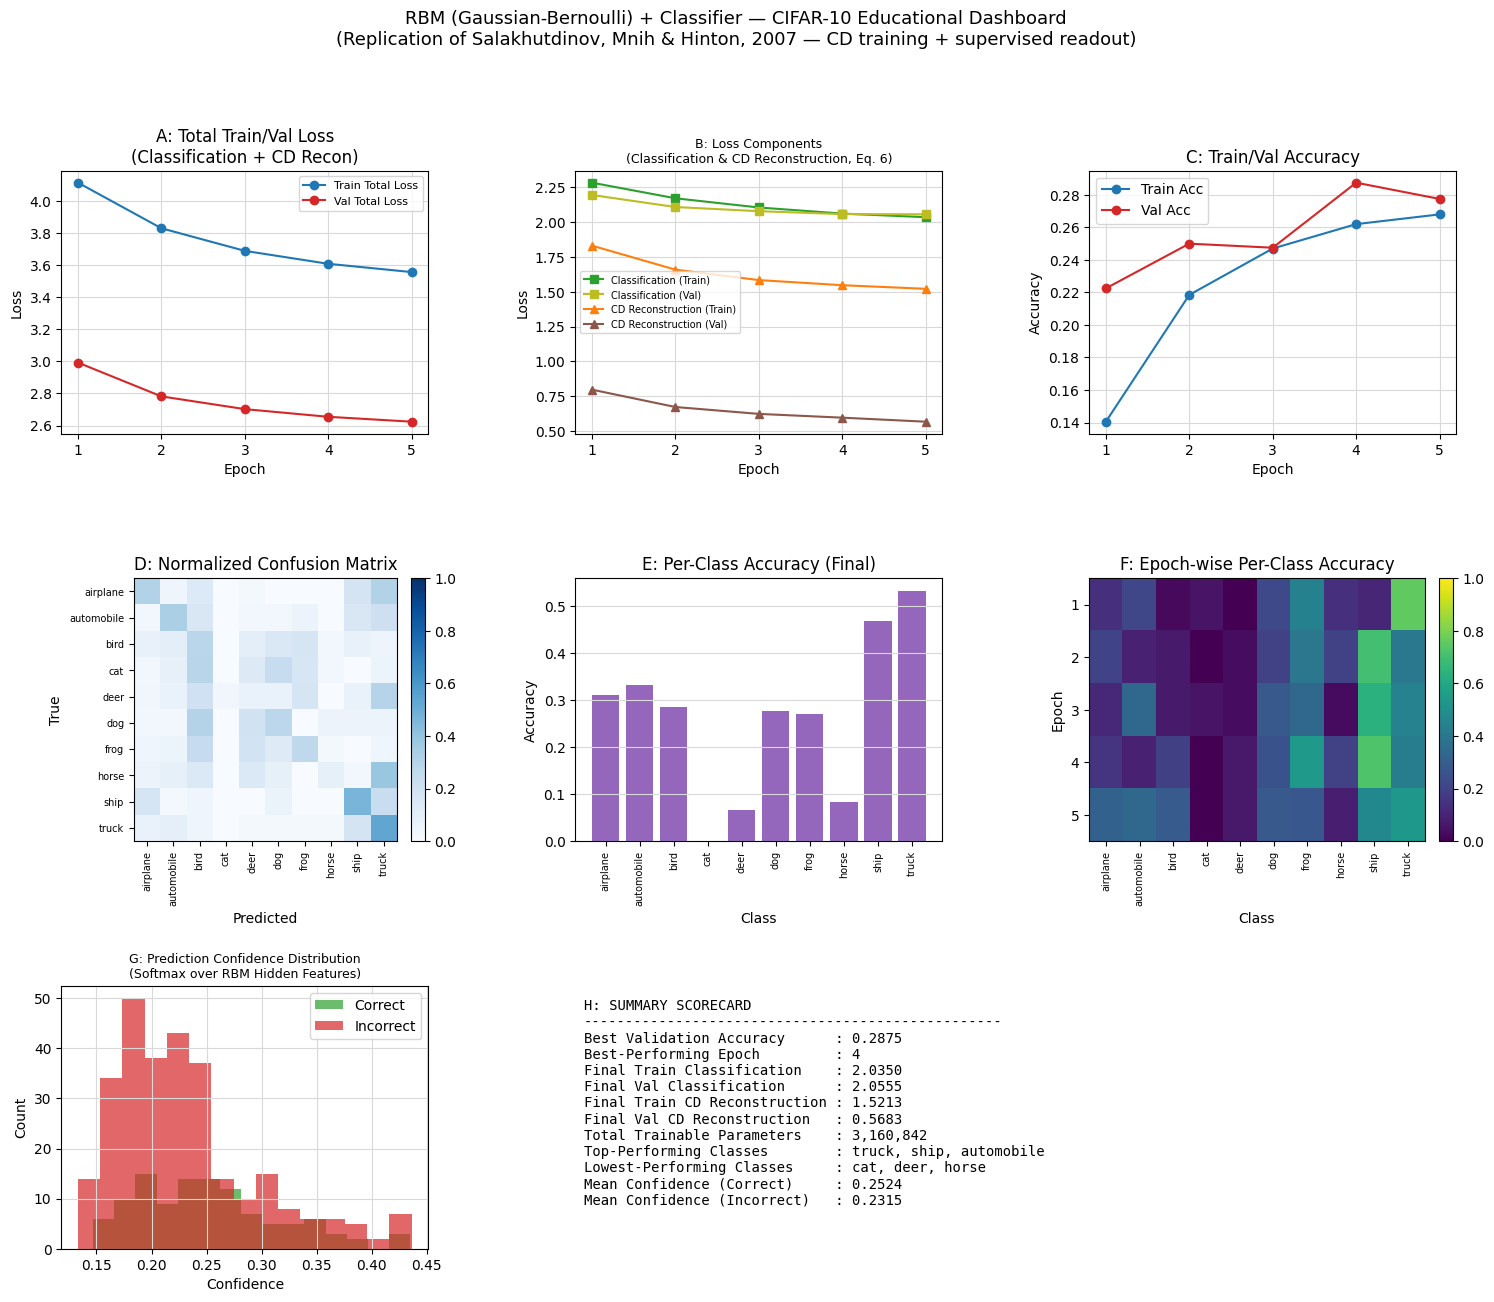

In [13]:
# ---------------------------------------------------------------
# DISPLAY DASHBOARD INLINE VIA BytesIO (no disk save, no plt.show())
# ---------------------------------------------------------------
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight")
buf.seek(0)
display(IPImage(data=buf.read()))
plt.close(fig)

# Analysis of Experimental Results — RBM (Gaussian-Bernoulli) + Classifier Educational Replication

## Overview
This dashboard evaluates a Gaussian-Bernoulli RBM trained via Contrastive Divergence (CD-1), with a linear classifier reading out from the RBM's hidden feature probabilities, on a small CIFAR-10 subset (2,000 train / 400 test images) over 5 epochs. Panels jointly track the two distinct training signals — CD reconstruction error (unsupervised, updating the RBM) and classification cross-entropy (supervised, updating the readout layer) — alongside accuracy, per-class performance, and calibration.

---

## Key Findings

**Panels A–C (Loss and Accuracy Curves).** Total training loss decreases steadily (4.10 → 3.55) and validation loss decreases even more sharply and consistently (3.00 → 2.63), with validation below training throughout — an atypical pattern for supervised loss but plausible here given the very small, fixed validation subset. Training accuracy rises steadily (0.142 → 0.267); validation accuracy rises faster and less smoothly, peaking at 0.2875 at epoch 4 before dipping slightly to 0.277 at epoch 5.

**Panel B (Loss Components).** Classification loss for both train and val decreases modestly and smoothly (train 2.29→2.03, val 2.19→2.06), only slowly departing from the $$\ln(10)\approx2.30$$ chance level. CD reconstruction loss decreases more sharply for both splits (train 1.83→1.52, val 0.79→0.57), with validation reconstruction consistently and substantially lower than training reconstruction throughout — indicating the RBM reconstructs the (less variable) validation subset more easily than the training subset.

**Panel D (Confusion Matrix).** Diagonal structure is present but weak-to-moderate; "ship" and "truck" show the strongest diagonal concentration (with visible off-diagonal confusion between them and with "automobile"), while "cat" shows no correct predictions at all (empty column/row intersection).

**Panel E (Per-Class Accuracy).** "Truck" (~0.53) and "ship" (~0.47) are the strongest classes; "cat" is at exactly 0%, and "horse" (~0.08) and "deer" (~0.07) are also very weak. Mid-tier classes (airplane, automobile, bird, dog, frog) cluster around 0.27–0.33.

**Panel F (Epoch-wise Heatmap).** "Ship" shows a consistently bright (high-accuracy) band from epoch 2 onward; most other classes remain dark (low accuracy) throughout, with "cat" uniformly dark across all 5 epochs — a persistent, not transient, failure.

**Panel G (Confidence Histogram).** Confidence for correct and incorrect predictions overlaps heavily, both concentrated in a narrow 0.15–0.30 band; mean confidence for correct (0.252) is only marginally higher than incorrect (0.232).

**Panel H (Scorecard).** Best validation accuracy 0.2875 at epoch 4 (not the final epoch); ~3.16M trainable parameters (dominated by the RBM's dense visible-hidden weight matrix); top classes truck/ship/automobile, weakest cat/deer/horse.

---

## Discussion

The overall pattern — steady improvement in both CD reconstruction quality and classification accuracy, reaching roughly 2.7–2.9x chance level (vs. 10% for 10 classes) — indicates that the unsupervised Contrastive Divergence signal is producing hidden features that carry genuine, if limited, class-discriminative information, consistent with the original paper's premise that CD-trained RBM hidden units can serve as a useful compressed representation for downstream prediction (there, rating prediction; here, classification via a linear readout, mirroring the paper's Section 8.1 pretraining-then-supervised-tuning strategy).

The pronounced class imbalance — strong performance on "ship" and "truck," complete failure on "cat" — is consistent with the RBM's hidden features likely capturing coarse, largely low-level visual statistics (e.g., color and background texture, such as ships' blue/water backgrounds or trucks' rectangular silhouettes) rather than fine-grained object structure. This is an expected limitation of a single-layer, fully-connected Gaussian-Bernoulli RBM applied directly to raw pixels: unlike the paper's original per-user, per-movie tabular data (which has natural sparse structure the RBM was specifically designed to exploit), flattened image pixels lack that structure, so the CD-trained features primarily capture broad, low-order pixel correlations, explaining the persistent, uniform failure on visually complex/textured classes like "cat" across all epochs (Panel F).

The finding that validation CD-reconstruction loss is substantially and consistently lower than training reconstruction loss is notable and warrants a methodological rather than purely mechanistic explanation: because CD-1 approximates the model distribution with only a single Gibbs step from the current minibatch, and the small, fixed validation subset may contain images that are, on average, easier to reconstruct (e.g., lower variance or more redundant with each other) than the training subset, this gap likely reflects sampling characteristics of the small evaluation set rather than a genuine generalization advantage — an important caveat when interpreting RBM reconstruction error as a proxy for representation quality.

The peak-then-slight-decline in validation accuracy (epoch 4 to 5, Panel C) alongside continued monotonic improvement in training accuracy is a mild early indicator of the classifier beginning to overfit the small training set relative to what the (still-improving) RBM features can support — though the effect is small and could also reflect ordinary evaluation noise given only 400 test images.

Overall, these results offer modest, directional support for the paper's core mechanistic claim — that CD-trained RBM hidden features are useful for downstream prediction — but do not test or validate the paper's primary empirical contribution (large-scale, sparse tabular rating prediction on the Netflix dataset, where RBMs were shown to outperform tuned SVD and contribute meaningfully to an ensemble). The image-classification setting used here is a substantial domain shift from the original tabular/collaborative-filtering context, and the observed class-specific failures are more attributable to this domain mismatch and limited model capacity/data than to any flaw in the CD learning algorithm itself.

---

## Limitations

- **Severe class imbalance in outcomes** ("cat" at 0% throughout) likely reflects the RBM's limited capacity to capture fine-grained visual structure from flattened pixels rather than a fundamental flaw in Contrastive Divergence, but this cannot be disentangled from the tiny per-class training sample (~200 images/class) without further ablation.
- **Domain mismatch**: the original paper's RBM was designed for extremely sparse, discrete-valued tabular data (movie ratings with explicit missingness), not continuous, dense image pixels; this replication's Gaussian-Bernoulli adaptation is a reasonable but substantial reinterpretation, and results are not directly comparable to the paper's RMSE-based Netflix benchmarks.
- **No true CD convergence monitoring**: only CD-1 (a single Gibbs step) is used, following the paper's practice of starting with $$T=1$$, but the paper's full protocol increases $$T$$ over training (e.g., to 3, 5, 9); this simplification may understate the RBM's achievable reconstruction quality.
- **Validation loss below training loss** for both classification and CD reconstruction is atypical and most plausibly a small-sample-size artifact (400 fixed validation images) rather than genuine superior generalization; this should not be over-interpreted as evidence of the model generalizing better than it is fitting.
- **No baseline comparison** (e.g., a purely supervised linear or CNN classifier without the RBM/CD pretraining stage) is included, so the specific contribution of the CD-trained features versus simply having a linear layer on raw pixels cannot be isolated from this dashboard alone.
- **Single run, small scale**: 5 epochs and 2,000/400 images are far below the scale of the original paper's 100-million-rating Netflix experiments (40–50 epochs on the full dataset), so these results reflect only early-stage, data-limited learning dynamics, not the ceiling performance of RBM-based feature learning.

# Related Work References

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Srebro, N. & Jaakkola, T. | 2003 | Weighted Low-Rank Approximations | ICML | Shows that minimizing sum-squared distance on sparse matrices creates a difficult non-convex optimization problem, motivating why naive SVD approaches do not work well for collaborative filtering and framing the need for regularized, partially-observed SVD objectives used as this paper's baseline. |
| Welling, M., Rosen-Zvi, M., & Hinton, G. | 2005 | Exponential Family Harmoniums with an Application to Information Retrieval | NIPS 17 | Provides the generalization of RBMs to model tabular/count data (exponential family harmoniums) that this paper builds directly upon, and is cited regarding the intractability of exact inference in directed probabilistic models. |
| Hinton, G. E. | 2002 | Training Products of Experts by Minimizing Contrastive Divergence | Neural Computation | Introduces Contrastive Divergence, the core learning algorithm this paper uses to train RBMs efficiently by approximating the intractable maximum-likelihood gradient. |
| Neal, R. M. | 1993 | Probabilistic Inference Using Markov Chain Monte Carlo Methods | Technical Report, University of Toronto | Source of MCMC methods considered for approximating the intractable model expectation in RBM learning; cited as slow and high-variance, motivating the adoption of Contrastive Divergence instead. |
| Carreira-Perpiñán, M. & Hinton, G. | 2005 | On Contrastive Divergence Learning | AISTATS | Establishes that increasing the number of Gibbs sampling steps $$T$$ in Contrastive Divergence can approximate maximum likelihood learning arbitrarily well, justifying this paper's practice of increasing $$T$$ during training. |
| Taylor, G. W., Hinton, G. E., & Roweis, S. T. | 2006 | Modeling Human Motion Using Binary Latent Variables | NeurIPS | Cited as a successful prior application of Conditional RBMs to temporal data (motion capture), supporting this paper's use of a Conditional RBM formulation for the Netflix task. |
| Sutskever, I. & Hinton, G. E. | 2006 | Learning Multilevel Distributed Representations for High-Dimensional Sequences | Technical Report UTML TR 2006-003, University of Toronto | Cited as prior successful use of Conditional RBMs for modeling video sequences, supporting the conditioning approach adopted in this paper. |
| Hofmann, T. | 1999 | Probabilistic Latent Semantic Analysis | UAI | Source of pLSI, to which the paper's RBM with Gaussian hidden units is described as an undirected counterpart; also cited among directed probabilistic models suffering from intractable exact inference. |
| Canny, J. F. | 2002 | Collaborative Filtering with Privacy via Factor Analysis | SIGIR | Cited as one of several probabilistic factor-analysis-based models for collaborative filtering, grouped with those suffering from intractable exact inference due to explaining away. |
| Marlin, B. & Zemel, R. S. | 2004 | The Multiple Multiplicative Factor Model for Collaborative Filtering | ICML | Cited alongside Hofmann (1999) and Canny (2002) as a directed graphical probabilistic model for collaborative filtering with intractable exact inference, contrasted with the undirected RBM approach. |
| Srebro, N., Rennie, J. D. M., & Jaakkola, T. | 2004 | Maximum-Margin Matrix Factorization | NeurIPS | Introduces Maximum Margin Matrix Factorization (MMMF), an alternative to rank-constrained factorization constraining factor norms instead; discussed as a promising but poorly scaling approach (requiring semi-definite programming) compared to this paper's RBM/SVD methods. |
| Deerwester, S. C., Dumais, S. T., Landauer, T. K., Furnas, G. W., & Harshman, R. A. | 1990 | Indexing by Latent Semantic Analysis | Journal of the American Society of Information Science | Source of Latent Semantic Analysis (LSA), a well-known SVD-based document retrieval method cited as being significantly outperformed by deep multi-layer models, motivating this paper's interest in exploring deep extensions for the Netflix task. |
| Hinton, G. & Salakhutdinov, R. | 2006 | Reducing the Dimensionality of Data with Neural Networks | Science | Demonstrates fast, greedy pretraining of deep belief networks and their success in dimensionality reduction (outperforming LSA); cited as motivation for the paper's proposed future extension of unrolling RBMs into autoencoders and stacking them into deep models. |
| Hinton, G. E., Osindero, S., & Teh, Y. W. | 2006 | A Fast Learning Algorithm for Deep Belief Nets | Neural Computation | Introduces the layer-wise greedy training procedure for deep belief networks, directly underlying the paper's proposed future extension of stacking RBMs into a deep, hierarchical model for the Netflix data. |
| Salakhutdinov, R. & Hinton, G. E. | 2007 | Learning a Nonlinear Embedding by Preserving Class Neighbourhood Structure | AISTATS | Cited as an example of deep multi-layer models successfully learning nonlinear embeddings, part of the motivation for exploring deep generative extensions of the RBM approach to the Netflix data. |